## Breast Cancer

### Übung: Random Forest

In [15]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, r2_score, confusion_matrix
from sklearn.model_selection import train_test_split

data = load_breast_cancer()

# Missing Values überprüfen
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print(df.isnull().sum())

# Normalisieren der Skalen (bei Feature Variablen)
scaler = StandardScaler()
y = data.target
X = pd.DataFrame(scaler.fit_transform(data.data), columns=data.feature_names)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modell trainieren
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X=X_train, y=y_train)

y_pred = random_forest.predict(X_test)

accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)
r2 = r2_score(y_true=y_test, y_pred=y_pred)

print("Accuracy: "+str(accuracy)+"\nR2: "+ str(r2))

cf_matrix = confusion_matrix(y_test, y_pred)
print(cf_matrix)


mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64
Accuracy: 0.9707602339181286
R2: 0.8743386243386243
[[ 59   4]
 [  1 107]]


### Übung: Random Forest – Feature Importance / Engineering

Top 10 Features Selected:
mean concave points     0.141934
worst concave points    0.127136
worst area              0.118217
mean concavity          0.080557
worst radius            0.077975
worst perimeter         0.074292
mean perimeter          0.060092
mean area               0.053810
worst concavity         0.041080
mean radius             0.032312
dtype: float64


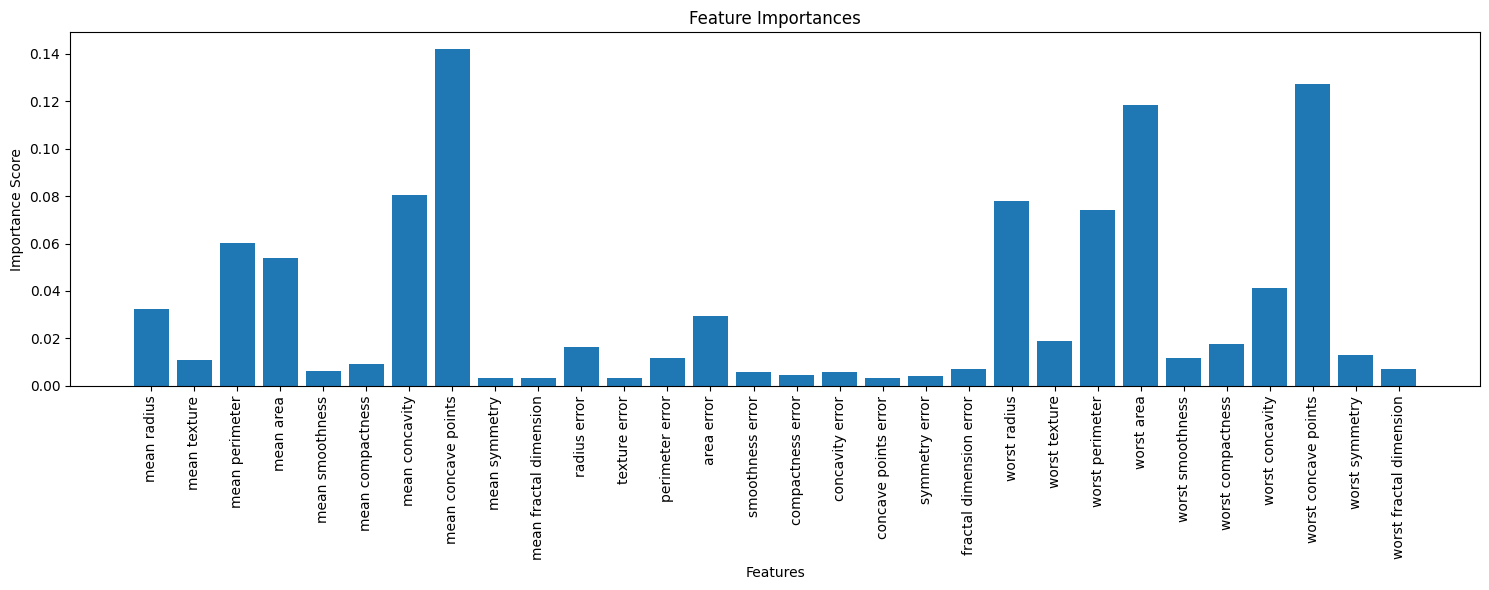

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        63
           1       0.97      0.98      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171

Confusion matrix:
[[ 60   3]
 [  2 106]]
Random Forest with Feature Engineering Accuracy: 0.9708



In [18]:
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

importances = random_forest.feature_importances_
feature_names = data.feature_names
feature_importances =  pd.Series(importances, index=feature_names)

# Auswahl top 10 features
top_features = feature_importances.sort_values(ascending=False)[:10]
print(f"Top 10 Features Selected:\n{top_features}")

plt.figure(figsize=(15,6))
plt.bar(range(len(importances)), importances, tick_label=feature_names)
plt.title("Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# X mit unseren top Merkmalen updaten
X_fe = X[top_features.index]
X_train_fe, X_test_fe, y_train_fe, y_test_fe =  train_test_split(X_fe, y, test_size=0.3, random_state=42)

# Random Forest mit top features neu traineren
rf_fe = RandomForestClassifier(random_state=42)
rf_fe = rf_fe.fit(X=X_train_fe, y=y_train_fe)
y_pred_fe = rf_fe.predict(X_test_fe)

# Ergebnisse evaluieren
print(f"Classification report:\n{classification_report(y_test_fe, y_pred_fe)}")
print(f"Confusion matrix:\n{confusion_matrix(y_test_fe, y_pred_fe)}")
rf_fe_accuracy = accuracy_score(y_test_fe, y_pred_fe)
print(f"Random Forest with Feature Engineering Accuracy: {rf_fe_accuracy:.4f}\n")


### Übung: XGBoost

In [19]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

print("Training XGBoost Classifier with Default Parameters...")
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb = xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print("XGBoost Model Trained.\n")

# XGBoost evaluieren
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

cf_matrix = confusion_matrix(y_test, y_pred_xgb)
print("XGBoost Confusion Matrix:")
print(cf_matrix)

accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy}\n")


Training XGBoost Classifier with Default Parameters...
XGBoost Model Trained.

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95        63
           1       0.98      0.96      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.97      0.96       171
weighted avg       0.97      0.96      0.97       171

XGBoost Confusion Matrix:
[[ 61   2]
 [  4 104]]
XGBoost Accuracy: 0.9649122807017544



c:\Users\jakob\Desktop\hfu\4_Semester\maschinelles_lernen\aufgaben\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:52:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Übung: XGBoost mit Grid Search

In [20]:
from sklearn.model_selection import GridSearchCV
print("Starting Hyperparameter Tuning for XGBoost...")

# Parameter grid definieren
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3]
}

# GridSearchCV initiieren
grid_search = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=0,
    n_jobs=-1
)

# GridSearchCV fitten
grid_search.fit(X_train, y_train)

# Die besten Parameter erhalten
best_params = grid_search.best_params_
print(f"Best Parameters Found: {best_params}\n")

# XGBoost mit den besten Parametern trainieren
print("Training Tuned XGBoost Classifier...")
best_xgb = grid_search.best_estimator_
best_xgb.fit(X_train, y_train)
y_pred_best_xgb = best_xgb.predict(X_test)
print("Tuned XGBoost Model Trained.\n")

# Das tuned XGBoost Modell evaluieren
print("Tuned XGBoost Classification Report:")
print(classification_report(y_test, y_pred_best_xgb))

print("Tuned XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_xgb))

tuned_xgb_accuracy = accuracy_score(y_test, y_pred_best_xgb)
print(f"Tuned XGBoost Accuracy: {tuned_xgb_accuracy:.4f}\n")

Starting Hyperparameter Tuning for XGBoost...
Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Training Tuned XGBoost Classifier...
Tuned XGBoost Model Trained.

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94        63
           1       0.95      0.97      0.96       108

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171

Tuned XGBoost Confusion Matrix:
[[ 58   5]
 [  3 105]]
Tuned XGBoost Accuracy: 0.9532



c:\Users\jakob\Desktop\hfu\4_Semester\maschinelles_lernen\aufgaben\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:52:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\jakob\Desktop\hfu\4_Semester\maschinelles_lernen\aufgaben\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:52:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Übung: LightGBM

In [22]:
from lightgbm import LGBMClassifier


print("Training LightGBM Classifier with Default Parameters...")
lgbm = LGBMClassifier(verbose=-1, random_state=42) #verbose=-1 unterdrueckt die Warnungen
lgbm = lgbm.fit(X_train, y_train)
y_lgbm_pred = lgbm.predict(X_test)
print("LightGBM Model Trained.\n")

# LightGBM evaluieren
print("LightGBM Classification Report:")
print(classification_report(y_test, y_lgbm_pred))

print("LightGBM Confusion Matrix:")
print(confusion_matrix(y_test, y_lgbm_pred))

lgbm_accuracy = accuracy_score(y_test, y_lgbm_pred)
print(f"LightGBM Accuracy: {lgbm_accuracy:.4f}\n")

Training LightGBM Classifier with Default Parameters...
LightGBM Model Trained.

LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171

LightGBM Confusion Matrix:
[[ 59   4]
 [  3 105]]
LightGBM Accuracy: 0.9591

